 **What Is Linear Regression?**

Linear regression is a supervised machine learning algorithm used to model the relationship between a dependent variable (target) and one or more independent variables (features). It assumes this relationship is linear, meaning it can be represented by a straight line:

y=β0​+β1​x1​+β2​x2​+⋯+βn​xn​+ε
- y: predicted value (target)
- x₁, x₂, ..., xₙ: input features
- β₀: intercept (value of y when all x = 0)
- β₁ to βₙ: coefficients (slopes showing impact of each feature)
- ε: error term
bold text

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Train.csv to Train.csv


In [2]:
# Step 1: Import necessary libraries
import pandas as pd                      # For data manipulation
import matplotlib.pyplot as plt          # For plotting graphs
import seaborn as sns                    # For enhanced visualizations
from sklearn.model_selection import train_test_split  # For splitting data
from sklearn.linear_model import LinearRegression      # For building the model
from sklearn import metrics              # For evaluating model performance


In [3]:
# Set a clean visual style for plots
sns.set_style('whitegrid')

# Step 2: Load your dataset
df = pd.read_csv('Train.csv')  # Replace with your actual file path



In [4]:
# Step 3: Preview the dataset
print("First 5 rows of the dataset:")
print(df.head())  # Display the top rows to inspect the structure



First 5 rows of the dataset:
   ID Warehouse_block Mode_of_Shipment  Customer_care_calls  Customer_rating  \
0   1               D           Flight                    4                2   
1   2               F           Flight                    4                5   
2   3               A           Flight                    2                2   
3   4               B           Flight                    3                3   
4   5               C           Flight                    2                2   

   Cost_of_the_Product  Prior_purchases Product_importance Gender  \
0                  177                3                low      F   
1                  216                2                low      M   
2                  183                4                low      M   
3                  176                4             medium      M   
4                  184                3             medium      F   

   Discount_offered  Weight_in_gms  Reached.on.Time_Y.N  
0                

In [5]:
# Step 4: Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())  # Ensure data is clean before modeling



Missing values in each column:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64


In [6]:
# Step 5: Select numerical features for regression
# These are the independent variables (predictors)
features = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

X = df[features]  # Feature matrix
y = df['Reached.on.Time_Y.N']  # Target variable (binary: 0 or 1)


In [7]:
# Step 6: Split the data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
# Step 7: Create and train the linear regression model
model = LinearRegression()         # Instantiate the model
model.fit(X_train, y_train)        # Fit the model to training data



LinearRegression()

In [9]:
# Step 8: Inspect model parameters
print("\nModel Parameters:")
print(f"Intercept (β₀): {model.intercept_:.2f}")  # y-intercept
print("Coefficients (β₁ to βₙ):")
for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.2f}")  # Slope for each feature



Model Parameters:
Intercept (β₀): 0.88
Coefficients (β₁ to βₙ):
Customer_care_calls: -0.02
Customer_rating: 0.00
Cost_of_the_Product: -0.00
Prior_purchases: -0.02
Discount_offered: 0.01
Weight_in_gms: -0.00


In [10]:
# Step 9: Make predictions on the test set
y_pred = model.predict(X_test)  # Predict target values


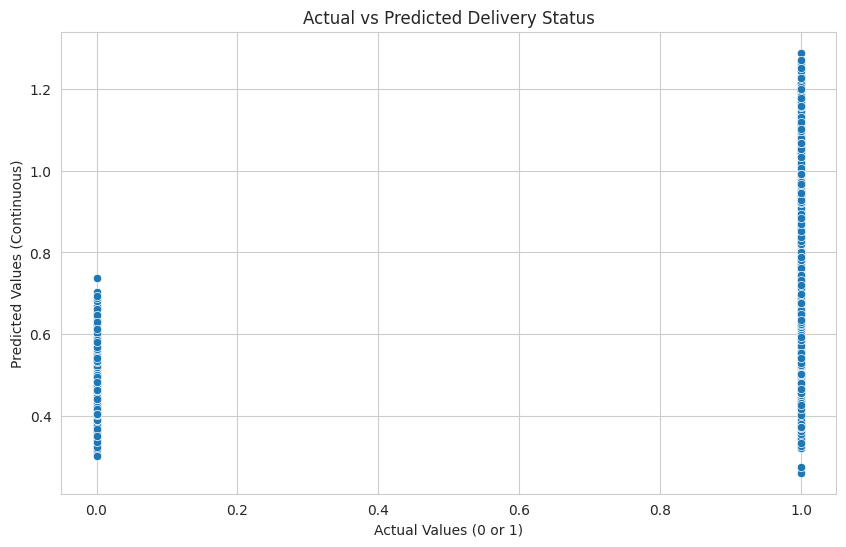

In [11]:
# Step 10: Visualize actual vs predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.title('Actual vs Predicted Delivery Status')
plt.xlabel('Actual Values (0 or 1)')
plt.ylabel('Predicted Values (Continuous)')
plt.show()


In [12]:
# Step 11: Evaluate model performance
print("\nModel Evaluation Metrics:")
mae = metrics.mean_absolute_error(y_test, y_pred)  # Average absolute error
mse = metrics.mean_squared_error(y_test, y_pred)   # Average squared error
r2 = metrics.r2_score(y_test, y_pred)              # R² score (goodness of fit)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")



Model Evaluation Metrics:
Mean Absolute Error (MAE): 0.41
Mean Squared Error (MSE): 0.20
R-squared (R²): 0.18
